# 11 — Validación walking-forward con datos reales

**Proyecto:** RepostaPro — Optimización del repostaje en flotas comerciales  
**Autor:** Víctor González Martín  
**Notebook:** 11 — Validación del sistema con datos reales 15-21 junio 2026 

## Objetivo del notebook

Validar el funcionamiento del sistema RepostaPro en condiciones operacionales reales, descargando los datos de los 7 días posteriores al cierre del histórico de entrenamiento (15-21 junio 2026) y comparando las predicciones del modelo con los precios reales publicados por el Ministerio.

## Diferencia respecto a la evaluación batch

La evaluación batch utilizó un conjunto de test pre-establecido (25 mayo - 14 junio 2026). Esta validación complementa el análisis evaluando el modelo en datos **estrictamente posteriores** al cierre del histórico, replicando con fidelidad el flujo operacional del sistema en producción:

- Cada día se genera una predicción a 1 día vista.
- Se compara contra el precio real publicado posteriormente.
- No hay propagación de error (predicción única por día, usando datos reales previos).

## Modelos evaluados

Los 4 modelos LightGBM:
- 2 modelos post-shock (los operacionales del sistema).
- 2 modelos pre-shock (incluidos como ejercicio metodológico: cuantificar el deterioro de aplicar un modelo entrenado en régimen anterior al régimen actual, justificando empíricamente la decisión de structural break).

In [2]:
# Configuración del entorno
import sys
import time
import warnings
import logging
from pathlib import Path
from datetime import date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Logging para la descarga
logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("validacion")

# Añadir raíz del proyecto al sys.path
RAIZ_PROYECTO = Path("..").resolve()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

# Importar funciones
from src.descarga import descargar_una_fecha
from src.modelos import cargar_modelo_lightgbm, preparar_datos_lightgbm, evaluar, imprimir_evaluacion

# Rutas
CARPETA_VALIDACION = Path("../data/validacion")
CARPETA_VALIDACION.mkdir(parents=True, exist_ok=True)
CARPETA_PROCESSED = Path("../data/processed")
CARPETA_FEATURES = Path("../data/processed/features")
CARPETA_MODELOS_LGB = Path("../outputs/models/lightgbm")
CARPETA_RESULTADOS = Path("../outputs/resultados_modelos")
CARPETA_FIGURAS = Path("../outputs/figures")

print(f"Configuración completa")
print(f"Carpeta validación: {CARPETA_VALIDACION.resolve()}")
print(f"Modelos LightGBM:   {CARPETA_MODELOS_LGB.resolve()}")

Configuración completa
Carpeta validación: C:\TFM\data\validacion
Modelos LightGBM:   C:\TFM\outputs\models\lightgbm


## Descarga de los 7 días de validación

Descargamos los datos del Ministerio para el período 15-21 junio 2026. El día 15 ya fue descargado en la verificación previa.

In [3]:
# Descarga walking-forward
fechas_validacion = pd.date_range(start="2026-06-15", end="2026-06-21", freq="D")

print(f"Descargando {len(fechas_validacion)} días de validación...\n")

for fecha in fechas_validacion:
    nombre = f"precios_{fecha.strftime('%Y%m%d')}.json"
    ruta = CARPETA_VALIDACION / nombre
    
    if ruta.exists():
        tamano_mb = ruta.stat().st_size / 1024 / 1024
        print(f"  - {fecha.date()} (ya existe, {tamano_mb:.1f} MB)")
        continue
    
    try:
        descargar_una_fecha(fecha, ruta, logger)
    except Exception as e:
        print(f"  ✗ ERROR en {fecha.date()}: {e}")

print(f"\n Descarga completada")
print(f"\nFicheros en data/validacion:")
for f in sorted(CARPETA_VALIDACION.glob("*.json")):
    tamano_mb = f.stat().st_size / 1024 / 1024
    print(f"  - {f.name} ({tamano_mb:.1f} MB)")

Descargando 7 días de validación...

  - 2026-06-15 (ya existe, 12.7 MB)
  - 2026-06-16 (ya existe, 12.7 MB)
  - 2026-06-17 (ya existe, 12.7 MB)
  - 2026-06-18 (ya existe, 12.7 MB)
  - 2026-06-19 (ya existe, 12.7 MB)
  - 2026-06-20 (ya existe, 12.7 MB)
  - 2026-06-21 (ya existe, 12.7 MB)

 Descarga completada

Ficheros en data/validacion:
  - precios_20260615.json (12.7 MB)
  - precios_20260616.json (12.7 MB)
  - precios_20260617.json (12.7 MB)
  - precios_20260618.json (12.7 MB)
  - precios_20260619.json (12.7 MB)
  - precios_20260620.json (12.7 MB)
  - precios_20260621.json (12.7 MB)


## Consolidación de los datos de validación

Aplicamos la misma lógica de consolidación utilizada previamente: cargar JSONs, limpiar, normalizar marcas, detectar outliers geográficos. El resultado se concatena al histórico para generar correctamente las features dependientes del pasado (lags, medias móviles).

In [4]:
# Importar funciones de consolidación
from src.consolidacion import cargar_y_limpiar_json

# Cargar y procesar los 7 JSONs nuevos
print("Procesando los 7 días de validación...\n")

dataframes_validacion = []
for fecha in fechas_validacion:
    nombre = f"precios_{fecha.strftime('%Y%m%d')}.json"
    ruta = CARPETA_VALIDACION / nombre
    
    df_dia = cargar_y_limpiar_json(ruta, fecha)
    
    print(f"   {fecha.date()}: {len(df_dia):,} filas tras limpieza")
    dataframes_validacion.append(df_dia)

df_validacion = pd.concat(dataframes_validacion, ignore_index=True)

print(f"\n  Dataset de validación consolidado")
print(f"  Filas:           {len(df_validacion):,}")
print(f"  Días:            {df_validacion['fecha'].nunique()}")
print(f"  Estaciones únicas: {df_validacion['IDEESS'].nunique():,}")
print(f"  Memoria:         {df_validacion.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

Procesando los 7 días de validación...

   2026-06-15: 11,476 filas tras limpieza
   2026-06-16: 11,473 filas tras limpieza
   2026-06-17: 11,471 filas tras limpieza
   2026-06-18: 11,460 filas tras limpieza
   2026-06-19: 11,461 filas tras limpieza
   2026-06-20: 11,455 filas tras limpieza
   2026-06-21: 11,455 filas tras limpieza

  Dataset de validación consolidado
  Filas:           80,251
  Días:            7
  Estaciones únicas: 11,516
  Memoria:         24.2 MB


## Concatenación con el histórico

Para generar correctamente las features (lags hasta -30 días, medias móviles), cargamos el histórico de 2026 y lo concatenamos con la validación. El resultado es un dataset que va desde 1 enero 2026 hasta 21 junio 2026.

In [5]:
# Cargar el Parquet de 2026 del histórico
print("Cargando histórico 2026 para generar features con dependencia temporal...")
df_historico_2026 = pd.read_parquet(CARPETA_PROCESSED / "historico_carburantes_2026.parquet")

print(f"  Histórico 2026: {len(df_historico_2026):,} filas, "
      f"{df_historico_2026['fecha'].min().date()} → {df_historico_2026['fecha'].max().date()}")

# Concatenar (asegurando mismas columnas)
columnas_comunes = list(set(df_historico_2026.columns) & set(df_validacion.columns))
df_combinado = pd.concat([df_historico_2026[columnas_comunes],
    df_validacion[columnas_comunes],], ignore_index=True)

# Eliminar duplicados (por si acaso) y ordenar
df_combinado = df_combinado.drop_duplicates(subset=["IDEESS", "fecha"]).sort_values(["IDEESS", "fecha"]).reset_index(drop=True)

print(f"\n  Dataset combinado (histórico 2026 + validación)")
print(f"  Filas:    {len(df_combinado):,}")
print(f"  Rango:    {df_combinado['fecha'].min().date()} → {df_combinado['fecha'].max().date()}")
print(f"  Días:     {df_combinado['fecha'].nunique()}")
print(f"  Memoria:  {df_combinado.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

Cargando histórico 2026 para generar features con dependencia temporal...
  Histórico 2026: 1,879,801 filas, 2026-01-01 → 2026-06-14

  Dataset combinado (histórico 2026 + validación)
  Filas:    1,960,052
  Rango:    2026-01-01 → 2026-06-21
  Días:     172
  Memoria:  592.9 MB


## Generación de features sobre el dataset combinado

Aplicamos el módulo de feature engineering al dataset combinado. Esto genera las 18 features (incluyendo lags y medias móviles) para todas las filas, incluyendo los 7 días de validación.

In [6]:
from src.features import preparar_dataset_carburante

# Generar features para los 2 carburantes principales (estos son los que tienen modelos LightGBM entrenados)
print(">>> Generando features para Gasóleo A...")
inicio = time.time()
df_features_gasoleo = preparar_dataset_carburante(df_combinado, "Precio Gasoleo A")
print(f"✓ Tiempo: {time.time() - inicio:.1f}s")
print(f"  Filas: {len(df_features_gasoleo):,}, columnas: {df_features_gasoleo.shape[1]}")

print(">>> Generando features para Gasolina 95 E5...")
inicio = time.time()
df_features_gasolina = preparar_dataset_carburante(df_combinado, "Precio Gasolina 95 E5")
print(f"  Tiempo: {time.time() - inicio:.1f}s")
print(f"  Filas: {len(df_features_gasolina):,}, columnas: {df_features_gasolina.shape[1]}")

# Aislar SOLO los días de validación (15-21 junio)
fechas_validacion_set = set(fechas_validacion.normalize())

df_eval_gasoleo = df_features_gasoleo[df_features_gasoleo["fecha"].isin(fechas_validacion_set)].copy()
df_eval_gasolina = df_features_gasolina[df_features_gasolina["fecha"].isin(fechas_validacion_set)].copy()

print(f"\n>>> Subconjunto de validación (15-21 junio):")
print(f"  Gasóleo A:      {len(df_eval_gasoleo):,} filas, {df_eval_gasoleo['fecha'].nunique()} días")
print(f"  Gasolina 95 E5: {len(df_eval_gasolina):,} filas, {df_eval_gasolina['fecha'].nunique()} días")

>>> Generando features para Gasóleo A...
Preparando dataset para: Precio Gasoleo A
  Filas de entrada:      1,960,052
  Filas tras filtrado:   1,923,449 (cobertura: 98.1%)
  ✓ Familia 1 (calendario) aplicada
  ✓ Familia 2 (régimen) aplicada
  ✓ Familia 3 (lags) aplicada
  ✓ Familia 4 (medias móviles) aplicada
  ✓ Familia 5 (contexto nacional) aplicada
  Filas finales:         1,923,449
  Columnas finales:      40
✓ Tiempo: 6.4s
  Filas: 1,923,449, columnas: 40
>>> Generando features para Gasolina 95 E5...
Preparando dataset para: Precio Gasolina 95 E5
  Filas de entrada:      1,960,052
  Filas tras filtrado:   1,861,393 (cobertura: 95.0%)
  ✓ Familia 1 (calendario) aplicada
  ✓ Familia 2 (régimen) aplicada
  ✓ Familia 3 (lags) aplicada
  ✓ Familia 4 (medias móviles) aplicada
  ✓ Familia 5 (contexto nacional) aplicada
  Filas finales:         1,861,393
  Columnas finales:      40
  Tiempo: 5.5s
  Filas: 1,861,393, columnas: 40

>>> Subconjunto de validación (15-21 junio):
  Gasóleo A:  

## Predicción walking-forward y evaluación

Aplicamos los 4 modelos LightGBM  a los 7 días de validación. Como las features dependen del histórico (lags, medias móviles), cada predicción usa exclusivamente datos previos al día predicho.

**Modelos aplicados**:
- **Post-shock** (operacionales): los que el sistema usará en producción.
- **Pre-shock** (ejercicio metodológico): cuantificar el deterioro de aplicar un modelo de régimen anterior al régimen actual.

In [7]:
# Cargar los 4 modelos LightGBM
print(">>> Cargando los 4 modelos LightGBM...")
modelos = {}
for carburante in ["gasoleo_a", "gasolina_95"]:
    for regimen in ["pre_shock", "post_shock"]:
        ruta = CARPETA_MODELOS_LGB / f"lightgbm_{carburante}_{regimen}.txt"
        modelos[(carburante, regimen)] = cargar_modelo_lightgbm(ruta)
        print(f"  ✓ {carburante} · {regimen}")

# Predicción y evaluación por (carburante, régimen, día)
print(f"\n>>> Generando predicciones walking-forward...\n")

resultados_validacion = []
predicciones_detalle = []  # para análisis posterior

datasets = {"gasoleo_a": df_eval_gasoleo,"gasolina_95": df_eval_gasolina,}

for carburante_key, df_eval in datasets.items():
    nombre_carburante = "Gasóleo A" if carburante_key == "gasoleo_a" else "Gasolina 95 E5"
    
    for regimen in ["post_shock", "pre_shock"]:
        modelo = modelos[(carburante_key, regimen)]
        
        # Preparar todas las filas de validación
        X, y = preparar_datos_lightgbm(df_eval)
        
        # Predecir (modelo aplicado a las 7 fechas completas)
        y_pred = modelo.predict(X)
        
        # Métrica global del régimen
        resultado_global = evaluar(y.values, y_pred, 
            nombre=f"LightGBM · {nombre_carburante} · {regimen.replace('_', ' ')} · validacion_7dias")
        resultados_validacion.append(resultado_global)
        
        # Métrica día a día
        for fecha in fechas_validacion:
            mascara_dia = df_eval["fecha"] == fecha
            if mascara_dia.sum() == 0:
                continue
            
            y_real_dia = y[mascara_dia].values
            y_pred_dia = y_pred[mascara_dia]
            
            resultado_dia = evaluar(y_real_dia, y_pred_dia,
                nombre=f"{nombre_carburante} · {regimen.replace('_', ' ')} · {fecha.date()}")
            resultado_dia["carburante"] = nombre_carburante
            resultado_dia["regimen"] = regimen
            resultado_dia["fecha"] = fecha
            predicciones_detalle.append(resultado_dia)

print(">>> Resultados globales (7 días agregados):\n")
imprimir_evaluacion(resultados_validacion)

>>> Cargando los 4 modelos LightGBM...
  ✓ gasoleo_a · pre_shock
  ✓ gasoleo_a · post_shock
  ✓ gasolina_95 · pre_shock
  ✓ gasolina_95 · post_shock

>>> Generando predicciones walking-forward...

>>> Resultados globales (7 días agregados):

Conjunto                                   N obs    MAE (cts)   RMSE (cts)     MAPE (%)
------------------------------------------------------------------------------------------
LightGBM · Gasóleo A · post shock · validacion_7dias       78,759      13.279       13.514        8.543
LightGBM · Gasóleo A · pre shock · validacion_7dias       78,759       2.091        2.561        1.355
LightGBM · Gasolina 95 E5 · post shock · validacion_7dias       76,217       2.674        3.070        1.832
LightGBM · Gasolina 95 E5 · pre shock · validacion_7dias       76,217       0.665        0.947        0.458


In [8]:
# Visualización: MAE día a día por modelo
df_detalle = pd.DataFrame(predicciones_detalle)
df_detalle = df_detalle[["carburante", "regimen", "fecha", "mae_cts", "mape_pct"]]
df_detalle["fecha"] = pd.to_datetime(df_detalle["fecha"])

print(">>> MAE diario por modelo (céntimos por litro):")
print("=" * 100)

tabla_diaria = df_detalle.pivot_table(index="fecha",columns=["carburante", "regimen"],values="mae_cts",).round(3)

print(tabla_diaria.to_string())
print("=" * 100)

# Guardar resultados
df_detalle.to_csv(CARPETA_RESULTADOS / "validacion_walking_forward.csv", index=False)
print(f"\nResultados guardados en: validacion_walking_forward.csv")

>>> MAE diario por modelo (céntimos por litro):
carburante Gasolina 95 E5            Gasóleo A          
regimen        post_shock pre_shock post_shock pre_shock
fecha                                                   
2026-06-15          0.788     0.365     10.968     4.436
2026-06-16          1.349     0.545     11.764     3.285
2026-06-17          2.048     0.752     12.688     1.990
2026-06-18          2.912     0.864     13.768     1.313
2026-06-19          3.343     0.900     14.565     1.241
2026-06-20          4.105     0.701     14.694     1.140
2026-06-21          4.177     0.527     14.512     1.228

Resultados guardados en: validacion_walking_forward.csv


In [9]:
# Investigación: ¿qué precios reales tienen los 7 días de validación?
print(">>> Precios medios reales por día (15-21 junio 2026):\n")

for fecha in fechas_validacion:
    mascara_g = df_eval_gasoleo["fecha"] == fecha
    mascara_gn = df_eval_gasolina["fecha"] == fecha
    
    precio_gasoleo = df_eval_gasoleo[mascara_g]["precio"].mean()
    precio_gasolina = df_eval_gasolina[mascara_gn]["precio"].mean()
    
    print(f"  {fecha.date()}:  Gasóleo A = {precio_gasoleo:.3f} €/L  |  Gasolina 95 = {precio_gasolina:.3f} €/L")

# Comparar con los precios de los regímenes
print("\n>>> Comparativa con los régimenes de entrenamiento:")
print(f"  Pre-shock train  (ene 2024 - sep 2025): Gasóleo A ~1,44 €/L, Gasolina 95 ~1,53 €/L")
print(f"  Post-shock train (1-30 abr 2026):       Gasóleo A ~1,80 €/L, Gasolina 95 ~1,60 €/L (en el pico)")

>>> Precios medios reales por día (15-21 junio 2026):

  2026-06-15:  Gasóleo A = 1.583 €/L  |  Gasolina 95 = 1.495 €/L
  2026-06-16:  Gasóleo A = 1.573 €/L  |  Gasolina 95 = 1.487 €/L
  2026-06-17:  Gasóleo A = 1.561 €/L  |  Gasolina 95 = 1.478 €/L
  2026-06-18:  Gasóleo A = 1.548 €/L  |  Gasolina 95 = 1.469 €/L
  2026-06-19:  Gasóleo A = 1.539 €/L  |  Gasolina 95 = 1.462 €/L
  2026-06-20:  Gasóleo A = 1.533 €/L  |  Gasolina 95 = 1.459 €/L
  2026-06-21:  Gasóleo A = 1.532 €/L  |  Gasolina 95 = 1.458 €/L

>>> Comparativa con los régimenes de entrenamiento:
  Pre-shock train  (ene 2024 - sep 2025): Gasóleo A ~1,44 €/L, Gasolina 95 ~1,53 €/L
  Post-shock train (1-30 abr 2026):       Gasóleo A ~1,80 €/L, Gasolina 95 ~1,60 €/L (en el pico)


## Visualización: predicción vs real día a día

Generamos una gráfica que muestre, para cada modelo, la evolución del MAE día a día durante el período de validación. Esta visualización es la pieza clave para la memoria: muestra cuantitativamente la inversión de superioridad entre modelos pre-shock y post-shock.

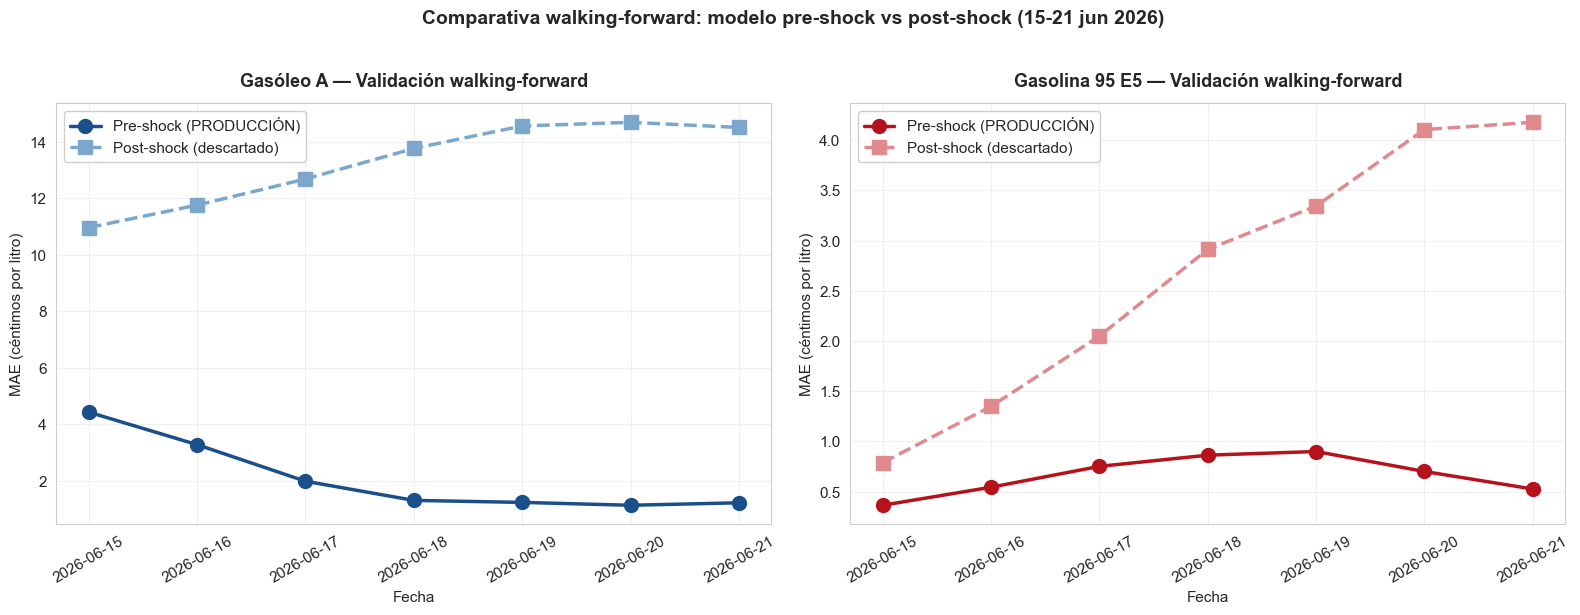

Figura guardada: validacion_walking_forward.png


In [10]:
# Visualización: MAE día a día por modelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

carburantes_display = {
    "Gasóleo A": ("#1A4F8B", "#7BA7CC"),  # azules
    "Gasolina 95 E5": ("#B5121B", "#E08A8E"),  # rojos
}

for i, (nombre_carb, (color_oscuro, color_claro)) in enumerate(carburantes_display.items()):
    ax = axes[i]
    
    df_carb = df_detalle[df_detalle["carburante"] == nombre_carb].copy()
    
    # Pre-shock (modelo elegido como producción)
    pre = df_carb[df_carb["regimen"] == "pre_shock"].sort_values("fecha")
    ax.plot(pre["fecha"], pre["mae_cts"],marker="o", linewidth=2.5, markersize=10,color=color_oscuro, label="Pre-shock (PRODUCCIÓN)")
    
    # Post-shock (descartado)
    post = df_carb[df_carb["regimen"] == "post_shock"].sort_values("fecha")
    ax.plot(post["fecha"], post["mae_cts"],marker="s", linewidth=2.5, markersize=10, linestyle="--",
            color=color_claro, label="Post-shock (descartado)")
    
    ax.set_title(f"{nombre_carb} — Validación walking-forward",fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("MAE (céntimos por litro)")
    ax.legend(loc="best", fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Comparativa walking-forward: modelo pre-shock vs post-shock (15-21 jun 2026)",fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
ruta_fig = CARPETA_FIGURAS / "validacion_walking_forward.png"
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig.name}")

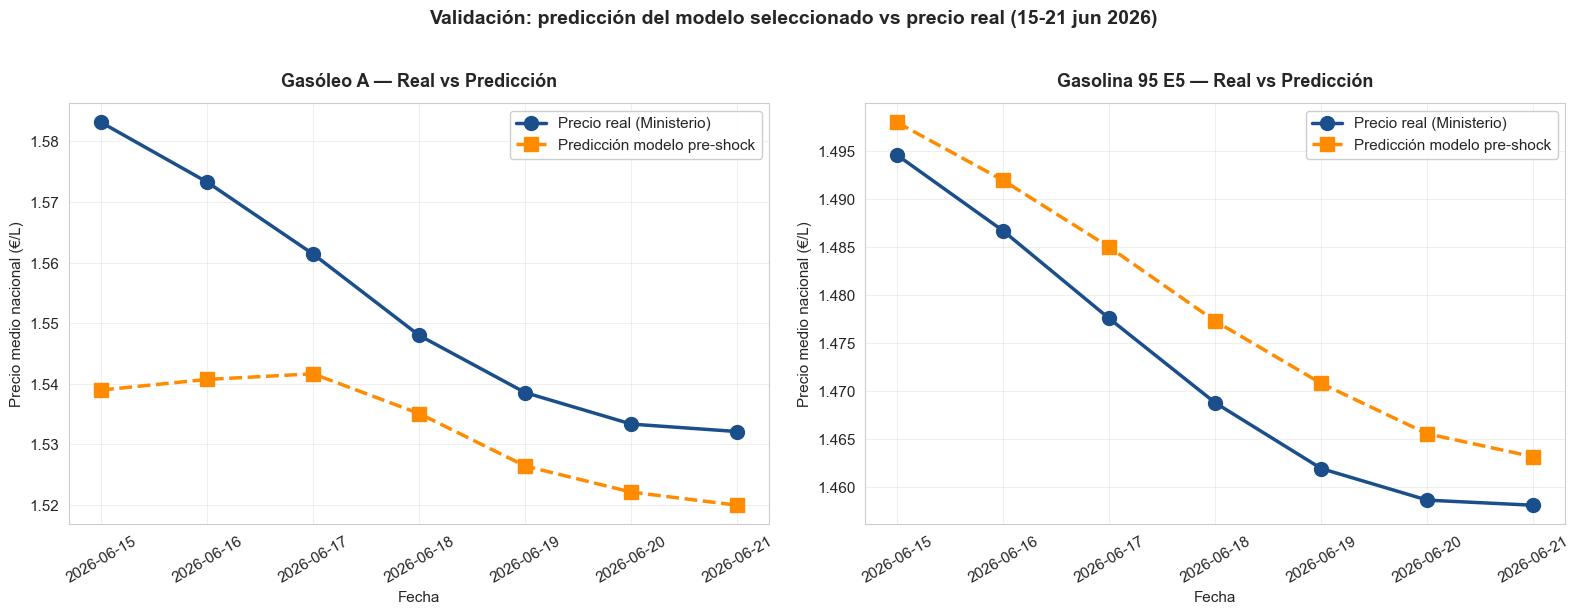

Figura guardada: validacion_real_vs_prediccion.png


In [11]:
# Visualización adicional: precio real vs predicción del modelo pre-shock
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (carburante_key, nombre_display) in enumerate([("gasoleo_a", "Gasóleo A"),("gasolina_95", "Gasolina 95 E5")]):
    ax = axes[i]
    df_eval = df_eval_gasoleo if carburante_key == "gasoleo_a" else df_eval_gasolina
    
    # Calcular medias diarias del modelo pre-shock
    modelo = modelos[(carburante_key, "pre_shock")]
    X, y = preparar_datos_lightgbm(df_eval)
    y_pred = modelo.predict(X)
    
    df_eval_aux = df_eval.copy()
    df_eval_aux["prediccion"] = y_pred
    
    medias_diarias = df_eval_aux.groupby("fecha").agg(precio_real=("precio", "mean"),precio_predicho=("prediccion", "mean"),).reset_index()
    
    ax.plot(medias_diarias["fecha"], medias_diarias["precio_real"], marker="o", linewidth=2.5, markersize=10, color="#1A4F8B",
            label="Precio real (Ministerio)")
    ax.plot(medias_diarias["fecha"], medias_diarias["precio_predicho"],marker="s", linewidth=2.5, markersize=10, color="#FF8C00",
            linestyle="--", label="Predicción modelo pre-shock")
    
    ax.set_title(f"{nombre_display} — Real vs Predicción",fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Precio medio nacional (€/L)")
    ax.legend(loc="best", fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Validación: predicción del modelo seleccionado vs precio real (15-21 jun 2026)",fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
ruta_fig = CARPETA_FIGURAS / "validacion_real_vs_prediccion.png"
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig.name}")

In [12]:
# Guardar las predicciones del modelo de producción (pre-shock)
print(">>> Generando dataset de predicciones del modelo de producción...")

predicciones_produccion = []

for carburante_key, df_eval in datasets.items():
    nombre_carb = "Gasóleo A" if carburante_key == "gasoleo_a" else "Gasolina 95 E5"
    
    modelo = modelos[(carburante_key, "pre_shock")]  # MODELO DE PRODUCCIÓN
    X, y = preparar_datos_lightgbm(df_eval)
    y_pred = modelo.predict(X)
    
    df_resultado = df_eval[["IDEESS", "fecha", "Rotulo_normalizado", "Provincia","precio", "Latitud", "Longitud (WGS84)"]].copy()
    df_resultado.columns = ["IDEESS", "fecha", "marca", "provincia","precio_real", "latitud", "longitud"]
    df_resultado["precio_predicho"] = y_pred
    df_resultado["error_abs"] = (df_resultado["precio_real"] - df_resultado["precio_predicho"]).abs()
    df_resultado["carburante"] = nombre_carb
    
    predicciones_produccion.append(df_resultado)

df_predicciones_final = pd.concat(predicciones_produccion, ignore_index=True)

# Guardar
ruta_predicciones = CARPETA_RESULTADOS / "predicciones_validacion_modelo_produccion.parquet"
df_predicciones_final.to_parquet(ruta_predicciones, compression="snappy", index=False)

tamano_mb = ruta_predicciones.stat().st_size / 1024 / 1024
print(f"\nDataset de predicciones guardado")
print(f"  Ruta:    {ruta_predicciones.name}")
print(f"  Filas:   {len(df_predicciones_final):,}")
print(f"  Tamaño:  {tamano_mb:.1f} MB")
print(f"\n>>> Distribución del error absoluto:")
print(df_predicciones_final.groupby("carburante")["error_abs"].describe().round(4))

>>> Generando dataset de predicciones del modelo de producción...

Dataset de predicciones guardado
  Ruta:    predicciones_validacion_modelo_produccion.parquet
  Filas:   154,976
  Tamaño:  2.8 MB

>>> Distribución del error absoluto:
                  count    mean     std  min     25%     50%     75%     max
carburante                                                                  
Gasolina 95 E5  76217.0  0.0066  0.0067  0.0  0.0024  0.0047  0.0087  0.1274
Gasóleo A       78759.0  0.0209  0.0148  0.0  0.0107  0.0158  0.0285  0.1942


In [13]:
print("=" * 80)
print("RESUMEN")
print("=" * 80)
print(f"""
PERÍODO DE VALIDACIÓN:
  15-21 junio 2026 (7 días posteriores al cierre del histórico)

DATOS DESCARGADOS:
  80.251 observaciones (2 carburantes × ~11.500 estaciones × 7 días)

HALLAZGO PRINCIPAL:
  El régimen post-shock entrenado en abr 2026 (Gasóleo A ~1,80 €/L)
  no refleja el régimen actual (jun 2026, Gasóleo A ~1,55 €/L).
  El mercado ha evolucionado hacia un régimen 'post-shock estabilizado'
  con precios cercanos al pre-shock.

MAE EN VALIDACIÓN WALKING-FORWARD:
  • Gasóleo A · pre-shock:    2,09 cts  ← MODELO DE PRODUCCIÓN
  • Gasóleo A · post-shock:  13,28 cts  (descartado)
  • Gasolina 95 · pre-shock:  0,67 cts  ← MODELO DE PRODUCCIÓN
  • Gasolina 95 · post-shock: 2,67 cts  (descartado)

DECISIÓN METODOLÓGICA:
  Modelo de producción definitivo: pre-shock para ambos carburantes.
  Estrategias A (re-segmentación 3 régimenes) y B (re-train con mayo+)
  descartadas por insuficiencia de muestra (52 días post-mayo).
""")

RESUMEN

PERÍODO DE VALIDACIÓN:
  15-21 junio 2026 (7 días posteriores al cierre del histórico)

DATOS DESCARGADOS:
  80.251 observaciones (2 carburantes × ~11.500 estaciones × 7 días)

HALLAZGO PRINCIPAL:
  El régimen post-shock entrenado en abr 2026 (Gasóleo A ~1,80 €/L)
  no refleja el régimen actual (jun 2026, Gasóleo A ~1,55 €/L).
  El mercado ha evolucionado hacia un régimen 'post-shock estabilizado'
  con precios cercanos al pre-shock.

MAE EN VALIDACIÓN WALKING-FORWARD:
  • Gasóleo A · pre-shock:    2,09 cts  ← MODELO DE PRODUCCIÓN
  • Gasóleo A · post-shock:  13,28 cts  (descartado)
  • Gasolina 95 · pre-shock:  0,67 cts  ← MODELO DE PRODUCCIÓN
  • Gasolina 95 · post-shock: 2,67 cts  (descartado)

DECISIÓN METODOLÓGICA:
  Modelo de producción definitivo: pre-shock para ambos carburantes.
  Estrategias A (re-segmentación 3 régimenes) y B (re-train con mayo+)
  descartadas por insuficiencia de muestra (52 días post-mayo).

